# McSharry Model 

+ is located under helpers/
+ simulates a single ECG channel
+ you can tune the frequency as well as how stronly each peak is pronounced

In [1]:
"""Integration functions for PQRST model."""
import numpy as np
from scipy.integrate import odeint


def f(y, t, arg_omega, arg_f2, arg_A, arg_ai):
    """Obtain temporal evolution of x, y, z.

    Constants are taken from https://doi.org/10.1109/tbme.2003.808805.

    Parameters:
    ------
    y : array 
        Array containing x, y, z values
    t : float
        Time point
    arg_omega : float
        Omega value
    arg_f2 : float
        f2 frequency value
    arg_A : float 
        Amplitude A value
    arg_ai: array
        Array containing the amplitude values ai for the P, Q, R, S and T peaks

    Returns:
    dy : array
        Array of temporal derivatives of x, y, z: dy=[dx, dy, dz]
    """
    # Constants
    theta_consts = np.array([-np.pi/3.0, -np.pi/12.0, 0.0, np.pi/12.0, np.pi/2.0])    
    b_consts = np.array([0.25, 0.1, 0.1, 0.1, 0.4])

    # Variables
    xx = y[0]
    yy = y[1]
    zz = y[2]

    alpha = 1-np.sqrt(xx**2+yy**2)
    theta = np.arctan2(yy, xx)
    dtheta = np.mod(theta-theta_consts, 2*np.pi)-np.pi
    z0 = arg_A*np.sin(2*np.pi*arg_f2*t)
    
    dxx = alpha*xx - arg_omega*yy
    dyy = alpha*yy + arg_omega*xx
    dzz = -np.sum(arg_ai*dtheta*np.exp(-dtheta**2/(2*b_consts**2)))-(zz-z0)    
    return [dxx, dyy, dzz]


def rsa_mayer(f = np.linspace(0.01, 0.5, 1000)):
    """Create RSA and Mayer wave Gaussian distribution.

    Helper function which creates Fourier spectrum, as described in https://doi.org/10.1109/tbme.2003.808805.

    Parameters:
    ------
    f : array
        Array containing the frequencies for which to create the spectrum

    Returns:
    ------
    s : array
        Fourier power spectrum containing the two peaks of the RSA and Mayer wave.
    """
    # Parameters
    sigma1 = 1e-1
    sigma2 = np.sqrt(2)*1e-1
    f1 = 0.1
    f2 = 0.25
    c1 = 0.01
    c2 = 0.01

    S = sigma1**2/np.sqrt(2*np.pi*c1**2)*np.exp(-(f-f1)**2/(2*c1**2)) + \
        sigma2**2/np.sqrt(2*np.pi*c2**2)*np.exp(-(f-f2)**2/(2*c2**2))
    return S


def integrate(tmin=10, tmax=20, T=5000, omega=2*np.pi, A=0.0, a_consts = np.array([1.2, -5.0, 30.0, -7.5, 0.75])):
    """Integrate PQRST model.
    
    Parameters:
    ------
    tmin : float
        Start time point of values to be returned
    tmax : float
        End time point of values to be returned
    T : float
        Number of time points to be returned
    omega : float
        Frequency of the oscillation (corresponding to hear rate)
    A : float 
        Amplitude A value of the baseline oscillation
    a_consts: array
        Array containing the amplitude values ai for the P, Q, R, S and T peaks

    Returns:
    sol : array (T, 3)
        Array of the solutions of x, y, z over the specified time window
    """

    dt = (tmax-tmin)/float(T)
    
    t = np.linspace(0, tmax, int(tmax/dt))
    f2 = 0.25

    # Initial condition
    y0 = [1.0, 0.0, 0.0] + 0.01*np.random.randn(3)

    sol = odeint(f, y0, t, args=(omega, f2, A, a_consts))
    return sol[int(tmin/dt):]


In [3]:
# Simulate with the default parameters

ecg_data = integrate()
print(ecg_data.shape)

(5000, 3)


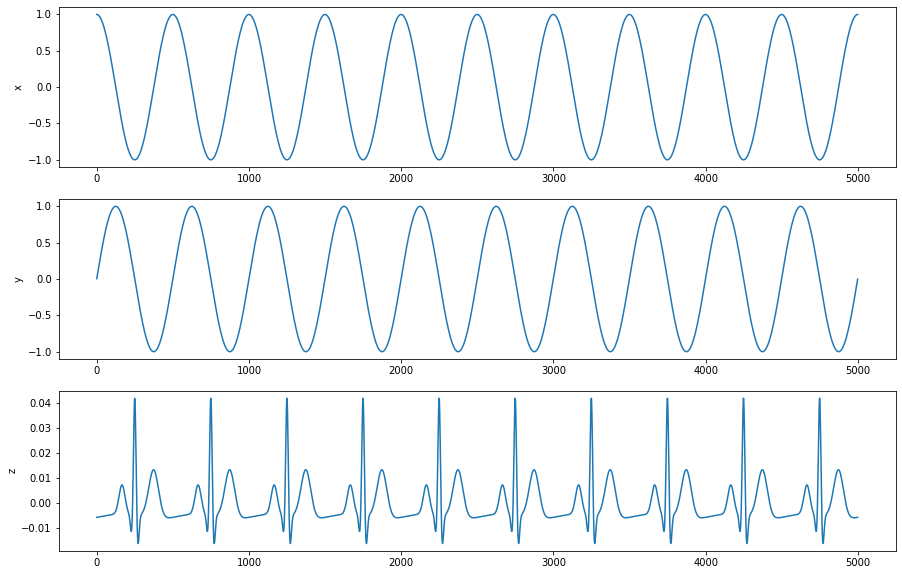

In [10]:
# Plot the results

import matplotlib.pyplot as plt
fig, axs = plt.subplots(3, figsize=(15, 10))
axs[0].plot(ecg_data[:, 0])
axs[0].set_ylabel('x')
axs[1].plot(ecg_data[:, 1])
axs[1].set_ylabel('y')
axs[2].plot(ecg_data[:, 2])
axs[2].set_ylabel('z')
plt.show()

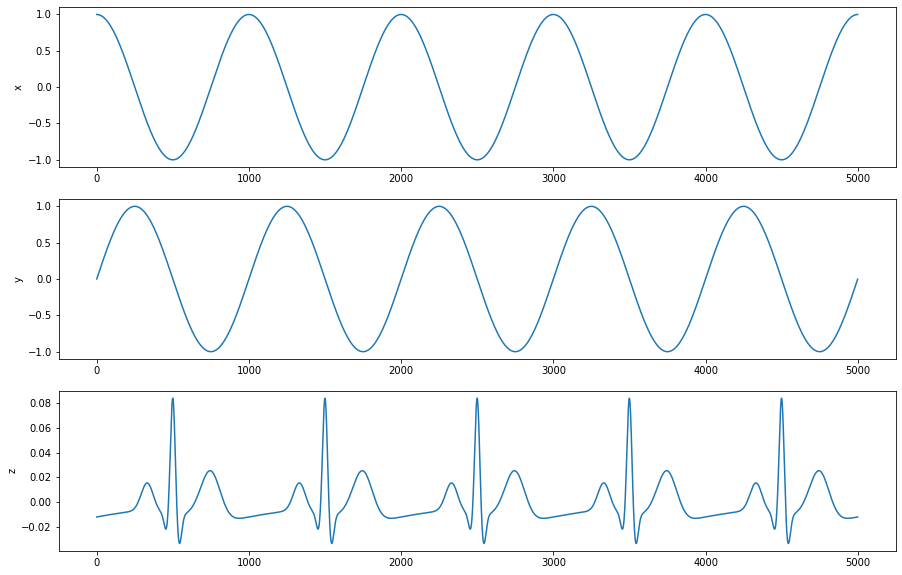

In [11]:
# Now change the frequency

ecg_data = integrate(omega=np.pi)
fig, axs = plt.subplots(3, figsize=(15, 10))
axs[0].plot(ecg_data[:, 0])
axs[0].set_ylabel('x')
axs[1].plot(ecg_data[:, 1])
axs[1].set_ylabel('y')
axs[2].plot(ecg_data[:, 2])
axs[2].set_ylabel('z')
plt.show()

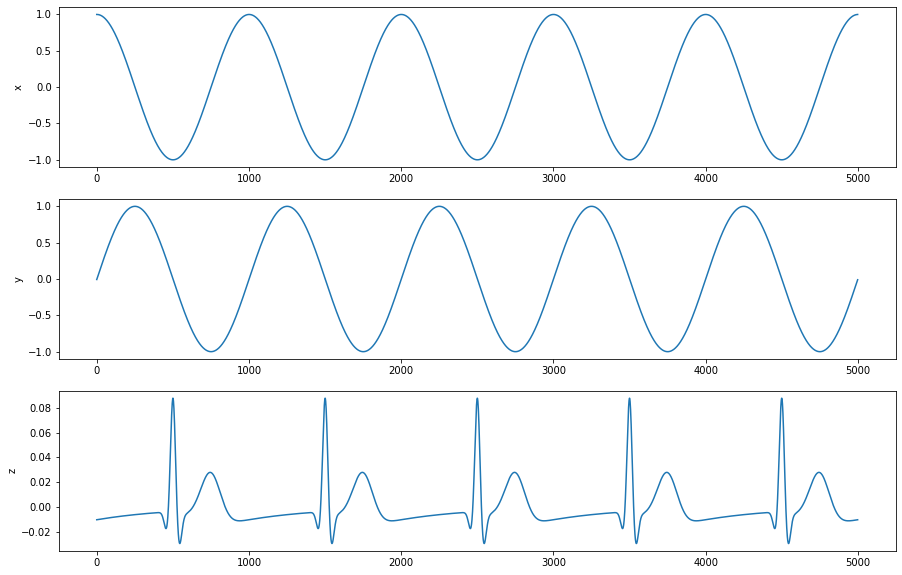

In [12]:
# Now remove P-wave

ecg_data = integrate(omega=np.pi, a_consts = np.array([0, -5.0, 30.0, -7.5, 0.75]))
fig, axs = plt.subplots(3, figsize=(15, 10))
axs[0].plot(ecg_data[:, 0])
axs[0].set_ylabel('x')
axs[1].plot(ecg_data[:, 1])
axs[1].set_ylabel('y')
axs[2].plot(ecg_data[:, 2])
axs[2].set_ylabel('z')
plt.show()